14.01.2026

# Проверка гипотез в бизнесе
Проект по аналитике крупного сервиса проката самокатов GoFast. Компания предоставила три датасета с данными о пользователях сервиса, их поездках за один год, а также стоимости услуг в подписках. Необходимо проанализировать демографию пользователей и особенности использования самокатов, а также определить возможную выгоду от распространения платной подписки на самокаты.

# Описание данных

Таблица с пользователями `users_go.csv`
- `user_id` — уникальный идентификатор пользователя.
- `name` — имя пользователя.
- `age` — возраст.
- `city` — город.
- `subscription_type` — тип подписки: `free`, `ultra`.

Таблица с поездками `rides_go.csv`
- `user_id` — уникальный идентификатор пользователя.
- `distance` — расстояние в метрах, которое пользователь проехал в текущей сессии.
- `duration` — продолжительность сессии в минутах, то есть время с того момента, как пользователь нажал кнопку «Начать поездку», до того, как он нажал кнопку «Завершить поездку».
- `date` — дата совершения поездки.
- 
Таблица с подписками `subscriptions_go.csv`
- `subscription_type` — тип подписки.
- `minute_price` — стоимость одной минуты поездки по этой подписке.
- `start_ride_price` — стоимость начала поездки.
- `subscription_fee` — стоимость ежемесячного платежа.

---
## Загрузка данных
На первом этапе загрузим все необходимые данные.

### Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.stats as st

### Чтение данных
Cчитайем и сохраним в отдельные датафреймы три CSV-файла. Датафреймы назовем в соответствии с названиями файлов, добавив префикс `df_`, например `df_users_go`. Для доступа к файлам используйте следующие ссылки:

- https://code.s3.yandex.net/datasets/users_go.csv
- https://code.s3.yandex.net/datasets/rides_go.csv
- https://code.s3.yandex.net/datasets/subscriptions_go.csv

In [2]:
df_users_go = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
df_rides_go =pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
df_subscriptions_go =pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

### Печать первых строк
Выведием первые пять строк каждого датафрейма. Познакомимся с содержанием таблиц.

In [3]:
display(df_users_go.head())
display(df_rides_go.head())
display(df_subscriptions_go.head())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


### Подсчёт строк
Определим количество строк в каждом из трёх датафреймов. Это поможет оценить объём данных и выявить аномалии, например слишком малое количество записей. Запишим три целых числа в одну строку через пробел.

In [4]:
print(df_users_go.shape[0], df_rides_go.shape[0], df_subscriptions_go.shape[0])

1565 18068 2


---
## Знакомство с данными и их предварительная подготовка

Прежде чем начать анализ, убедимся в качестве предоставленных данных. Выполним несколько шагов, чтобы лучше понять структуру и устранить потенциальные проблемы в таблицах.

### Определение типов данных
В датафрейме `df_rides_go` выведим типы данных каждой колонки стандартным атрибутом `dtypes`. Проверим корректность типов и подготовим данные для дальнейшей обработки.

In [5]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

### Преобразование формата даты
Приведем столбец `date` в датафрейме `df_rides_go` к типу даты pandas, используя метод `pd.to_datetime()`. Этот шаг упростит работу с временными данными.

In [6]:
df_rides_go['date']=pd.to_datetime(df_rides_go['date'])

### Созданим столбец с месяцем
На основе столбца `date` создадим новый столбец `month`, содержащий номер месяца. 

In [7]:
df_rides_go['month'] = df_rides_go['date'].dt.month

### Поиск дублей и пропусков
В датафрейме пользователей `df_users_go` определим количество пропусков и дубликатов. Это необходимо для понимания полноты и уникальности данных пользователей. Ответ выведим в виде двух целых чисел, разделённых пробелом. Например: `10 20`.

In [8]:
missing_values = df_users_go.isnull().sum().sum()
duplicates = df_users_go[df_users_go.duplicated()].shape[0]
print(missing_values, duplicates)


0 31


### аполнение пропусков и удаление дублей
При наличии пропущенных значений заполним их нулями, а все дубликаты удалим 

In [9]:
df_users_go.fillna(0, inplace=True)
df_users_go.drop_duplicates(inplace=True)


### Округлим длительности поездки
В датафрейме поездок `df_rides_go` округлим время поездки `duration` до целого числа стандартным методом `round()`. Затем приведем эту колонку к целочисленному типу `int`. 

In [10]:
df_rides_go['duration'] = df_rides_go['duration'].round().astype(int)

---
## Исследовательский анализ данных (EDA)

### Количество пользователей по городам.
Пользуясь данными из датафрейма `df_users_go`, изучим количество пользователей в каждом из городов. Создадим и выведем на экран объект `pd.Series`, названный `users_by_city_count`, с одной колонкой `count` — суммарным количеством пользователей в каждом городе `city`, отсортированным по убыванию.

In [11]:
users_by_city_count = df_users_go['city'].value_counts().sort_values(ascending=False)
print(users_by_city_count)

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64


### Количество пользователей подписки
Создадим и выведим на экран серию `subscription_type_count` с количеством пользователей для каждого типа подписки `subscription_type`.

In [12]:
subscription_type_count=df_users_go['subscription_type'].value_counts()
print(subscription_type_count)


subscription_type
free     835
ultra    699
Name: count, dtype: int64


### Круговая диаграмма
Построим круговую диаграмму, указав процент пользователей с `free` и `ultra` подпиской. Вызовим метод `plot()` для серии `subscription_type_count` с указанием нужного аргумента для построения круговой диаграммы.

Затем добавим следующее:
- **Заголовок.** Установим заголовок с помощью параметра `title`, задав его как `'Соотношение пользователей с подпиской и без подписки'`.
- **Процентные метки.** Используем параметр `autopct='%.0f%%'` для отображения процентных значений на диаграмме. Достаточно передать аргумент в указанном виде методу `plot()`. Процентные метки часто хорошо дополняют круговые диаграммы.
- **Подпись оси Y.** Установим пустую строку для подписи оси Y `(ylabel='')`, чтобы она не отображалась.
- **Цвета секторов.** Используем параметр `colors`, задав красный цвет `red` для пользователей без подписки и зелёный `green` для подписчиков.

Затем вызовим `plt.show()` для отображения диаграммы.

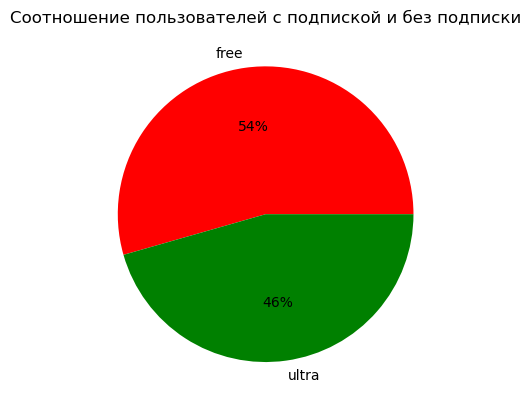

In [13]:
subscription_type_count.plot(
    kind='pie',
    title='Соотношение пользователей с подпиской и без подписки',
    autopct='%.0f%%',  # Процентные метки
    ylabel='',         # Ось Y без подписи
    colors=['red', 'green']  # Цвета секторов
)

plt.show()  # Отображение диаграммы

### Гистограмма возрастов
Построим гистограмму возрастов `age` пользователей самокатов. Используем количество бинов, равное разности максимального и минимального значений возраста.

Что нужно сделать:

1. Определить количество бинов `n_bins` как разницу между максимальным и минимальным значениями в столбце `age`.
2. Использовать метод `hist()` для столбца `df_users_go['age']`.
3. Установить количество бинов через параметр `bins=n_bins`.
4. Назначить заголовок графика как `'Возраст пользователей'` с помощью `plt.title()`.
5. Установить подпись оси X как `'Возраст'` с помощью `plt.xlabel()`.
6. Вызвать `plt.show()` для визуального отображения гистограммы.

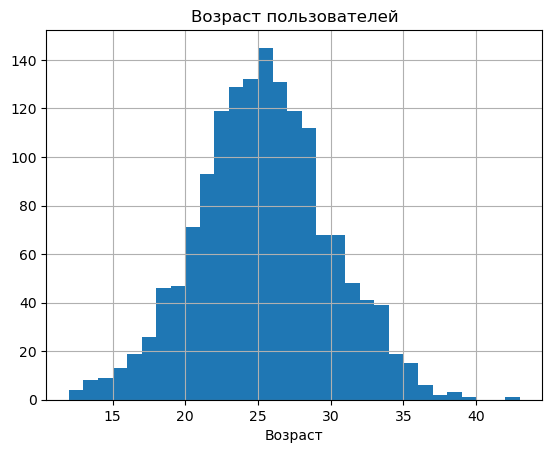

In [14]:
# Определяем количество бинов как разницу между максимальным и минимальным значениями возраста
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

# Строим гистограмму
df_users_go['age'].hist(bins=n_bins)

# Устанавливаем заголовок и подписи осей
plt.title('Возраст пользователей')
plt.xlabel('Возраст')

# Отображаем гистограмму
plt.show()

### Задача 3.6 Несовершеннолетние пользователи
Рассчитайтаем долю несовершеннолетних (возрастом менее 18 лет) пользователей самокатов.

In [15]:
users_under_18_ratio = round(100 * (df_users_go['age'] < 18).sum() / df_users_go['age'].shape[0])
print(f"Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.")

Доля несовершеннолетних пользователей самокатов составляет 5%.


### Характеристики длительности поездки
Длительность поездки является важной метрикой в работе сервиса проката самокатов. Если средняя длительность поездок будет слишком высокой, самокаты будут быстрее выходить из строя. Если слишком низкой, значит, клиентам что-то не нравится в сервисе.

С помощью описательной статистики изучим длительность поездок:

1. Используем колонку `duration` из датафрейма `df_rides_go`.
2. Расчитаем среднее значение и стандартное отклонение длительности поездки. Для расчёта стандартного отклонения можно воспользоваться методом `std()`.
3. Рассчитаем 25-й и 75-й процентили длительности поездки.
4. Выведем на экран ответ по предложенному шаблону.

In [16]:
duration_mean = int(df_rides_go['duration'].mean().round())
duration_std = int(df_rides_go['duration'].std())

duration_pct25 = int(df_rides_go['duration'].quantile(0.25))
duration_pct75 = int(df_rides_go['duration'].quantile(0.75))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


---
## Объединение данных



### Объединение таблицы пользователей и поездок
Объединим датафреймы с информацией о пользователях `df_users_go` и поездках `df_rides_go`. Полученный датафрейм назовем `df`. При объединении используем метод `merge()` по общей для двух таблиц колонке и тип объединения `left`.

In [17]:
df = pd.merge(df_users_go, df_rides_go, on='user_id', how='left')

### Присоединение информации о подписках
Присоединим к полученному датафрейму `df` информацию о подписках из `df_subscriptions_go`, используя метод `merge()` по общей колонке и тип объединения `left`.


In [18]:
df = pd.merge(df, df_subscriptions_go, on='subscription_type', how='left')

### Размеры объединённого датафрейма
Для финальной проверки выведем на экран первые пять строк датафрейма, а также количество строк и столбцов полученного датафрейма `df`. Этот этап позволит убедиться, что никакие записи не потерялись при объединении.

In [19]:
# Выводим первые строки датафрейма
display(df.head(5))

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


### Отдельные датафреймы для пользователей с подпиской и без
Создадим два вспомогательных датафрейма на основе `df`: первый только для пользователей с подпиской `df_ultra` и второй только для пользователей без подписки `df_free`. В следующих заданиях два этих датафрейма пригодятся при изучении поведения пользователей с подпиской и без, а также при проверке продуктовых гипотез.

In [20]:
# Фильтруем датафрейм для пользователей с подпиской ultra
df_ultra = df[df['subscription_type'] == 'ultra']

# Фильтруем датафрейм для пользователей без подписки (free)
df_free = df[df['subscription_type'] == 'free']


### Гистограмма длительности поездок для обоих групп
На одном графике построим гистограмму распределения длительности поездок `duration` для пользователей с подпиской и без.

Что нужно сделать:

1. Установить размер графика: 15 по горизонтали и 5 по вертикали. Использовать `plt.figure(figsize=(15, 5))`.
2. Отобразить данные из столбца `duration` датафрейма `df_free` с помощью метода `hist()`, задав количество бинов `bins=30` и метку `label='free'`.
3. Отобразить данные из столбца `duration` датафрейма `df_ultra` с помощью метода `hist()`, также задав количество бинов `bins=30` и метку `label='ultra'`.
4. Установить подпись оси X как `'Длительность поездки, мин.'`, используя `plt.xlabel()`.
5. Задать заголовок графика как `'Гистограмма распределения длительности поездок'` методом `plt.title()`.
6. Добавить легенду для различения категорий на графике с использованием `plt.legend()`.
7. Вызвать `plt.show()` для показа графика пользователю.

Для удобства воспользуйтесь датафреймами, созданными на прошлом шаге, — `df_ultra` и `df_free`.

Дополнительно рассчитаем среднюю длительность поездки для пользователей с подпиской и без, округлив ее до целых стандартной функцией `round` и распечатайте на экран при помощи шаблона.

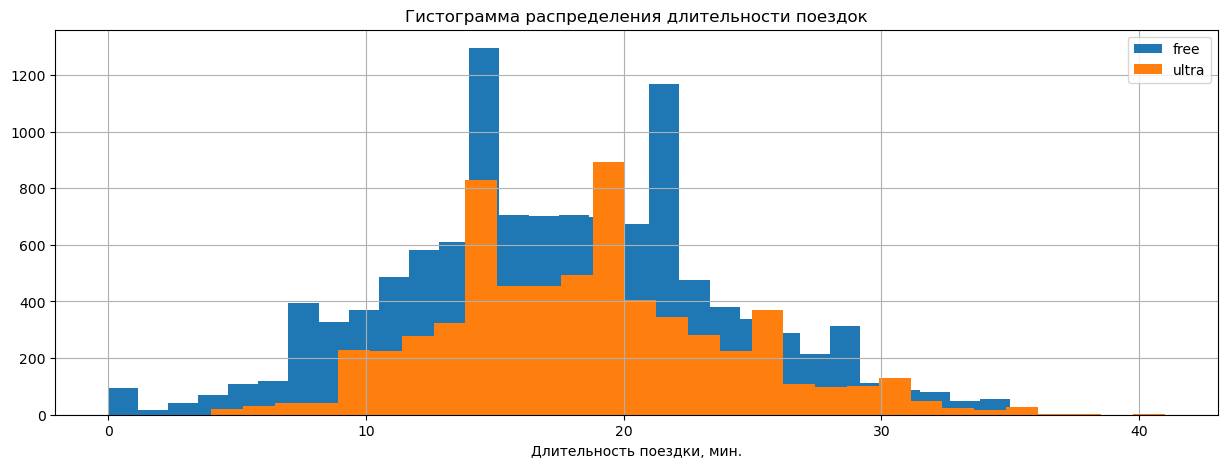

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [21]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))
df_free['duration'].hist(bins=30, label='free')
df_ultra['duration'].hist(bins=30, label='ultra')

# Устанавливаем подпись оси X
plt.xlabel('Длительность поездки, мин.')

# Задаем заголовок графика
plt.title('Гистограмма распределения длительности поездок')

# Добавляем легенду
plt.legend()

plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = int(df_free['duration'].mean().round())
mean_duration_ultra = int(df_ultra['duration'].mean().round())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

---
## Подсчёт выручки
Данные о количестве и длительности поездок объединены с ценами и тарифами, а значит, теперь есть всё необходимое, чтобы рассчитать важный для бизнеса показатель — выручку.

### Данные сгруппированные по нужным колонкам
Сгруппируем данные по следующим столбцам: `user_id`, `name`, `subscription_type`, `month`. Группировку производем в датафрейме `df_gp`. В итоговом датафрейме `df_gp` сохраним порядок агрегации изначальных столбцов и без использования групповых индексов (опция `as_index=False`).

In [22]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

### Подсчёт агрегированных метрик
Создадим новый датафрейм `df_agg`. В нём для каждой группы рассчитаем и добавим в датафрейм следующие агрегированные значения, используя метод `agg()`:
- `total_distance` — сумма значений в столбце `distance`.
- `total_duration` — сумма значений в столбце `duration`.
- `rides_count` — количество элементов в столбце `duration`.
- `subscription_type` — первое значение в группе для столбца `subscription_type`.
- `minute_price` — первое значение в группе для столбца `minute_price`.
- `start_ride_price` — первое значение в группе для столбца `start_ride_price`.
- `subscription_fee` — первое значение в группе для столбца `subscription_fee`.

In [23]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
)

### Функция для подсчёта выручки
Создадим функцию `calculate_monthly_revenue(row)` для расчёта месячной выручки по формуле:

`monthly_revenue` = `start_ride_price` * `rides_count` + `minute_price` * `total_duration` + `subscription_fee`

В качестве входных данных функция будет принимать одну строку `row` датафрейма. 
Здесь:
- `start_ride_price * rides_count` — выручка от начала каждой поездки.
- `minute_price * total_duration` — выручка за время использования.
- `subscription_fee` — фиксированная выручка от подписок.

In [24]:
def calculate_monthly_revenue(row):
    return row['start_ride_price'] * row['rides_count'] + row['minute_price'] * row['total_duration'] + row['subscription_fee']

### Созданим столбец с месячной выручкой на пользователя
Создадим новый столбец с месячной выручкой на пользователя `monthly_revenue`. Используем функцию `calculate_monthly_revenue(row)` к каждой строке агрегированного датафрейма `df_agg`.

In [25]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

### Поиск пользователя с максимальной выручкой
Исследуем полученные значения выручки. Найдем пользователя с максимальной суммарной выручкой за весь период наблюдения и для него выведем на экран `user_id`, имя, месяц, количество поездок и выручку за каждый из месяцев.

In [26]:
# Суммарная выручка по каждому пользователю
total_revenue_per_user = df_agg.groupby('user_id')['monthly_revenue'].sum()

# user_id с максимальной выручкой
max_user_id = total_revenue_per_user.idxmax()

# Фильтрация исходных данных по этому пользователю
user_data = df_agg[df_agg['user_id'] == max_user_id]

# Вывод нужных столбцов
print(user_data[['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']])

      user_id       name  month  rides_count  monthly_revenue
8877     1236  Александр      1            2              228
8878     1236  Александр      2            3              614
8879     1236  Александр      3            5              762
8880     1236  Александр      4            1              202
8881     1236  Александр      5            3              574
8882     1236  Александр      6            1              282
8883     1236  Александр      7            1              290
8884     1236  Александр      8            2              452
8885     1236  Александр      9            1              122
8886     1236  Александр     10            3              430
8887     1236  Александр     11            3              494
8888     1236  Александр     12            2              476


---
## Проверка гипотез

### Вспомогательная функция для интерпретации результатов
Напишем вспомогательную функцию `print_stattest_results(p_value, alpha)`, которая будет интерпретировать результаты статистического теста на основе p-value и заданного уровня значимости (α-уровня). Функция должна решать, следует ли принять альтернативную гипотезу или сохранить нулевую гипотезу.

У функции два параметра:
- `p_value` (тип `float`) — значение p-value, полученное в результате выполнения статистического теста.
- `alpha` (тип `float`, необязательный, по умолчанию `alpha = 0.05`) — уровень значимости статистического теста, который используется как порог для принятия решения об отклонении нулевой гипотезы.

In [27]:
def print_stattest_results(p_value: float, alpha: float = 0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### Длительность для пользователей с подпиской и без

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Сформулируем нулевую и альтернативную гипотезы:
- Нулевая гипотеза (Н0): Среднее время поездки у пользователей с подпиской и без подписки одинаковое.
- Альтернативная гипотеза (Н1): Среднее время поездки у пользователей с подпиской больше, чем у пользователей без подписки.

Чтобы проверить эту гипотезу:
1. Используйте неагрегированные данные из датафреймов `df_ultra` и `df_free`, созданные на одном из прошлых шагов.
2. Используйте данные о продолжительности каждой поездки `duration` — отдельно для подписчиков и тех, у кого нет подписки.
3. Рассчитайте значение `p_value` для выбранной гипотезы, используя функции модуля `scipy.stats` и односторонний t-тест.
4. В качестве результата вызовите написанную функцию `print_stattest_results(p_value, alpha)`, передав ей рассчитанное значение `p_value`.
5. В конце дополнительно рассчитайте среднюю длительность поездки для тарифов `ultra` и `free`, округлив её до двух знаков после точки стандартной функцией `round()`.

In [28]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration,alternative='greater') # Укажите подходящий инструмент здесь
p_value = results.pvalue

print_stattest_results(p_value)
ultra_mean_duration =round(df_ultra['duration'].mean(),2)
free_mean_duration =round(df_free['duration'].mean(),2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


In [29]:
display(df_ultra.head())
display(df_agg.head())

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


,user_id,name,month,total_distance,total_duration,rides_count,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_revenue
0,1,Кира,1,7027.511294,42,2,ultra,6,0,199,451
1,1,Кира,4,754.159807,6,1,ultra,6,0,199,235
2,1,Кира,8,6723.470560,45,2,ultra,6,0,199,469
3,1,Кира,10,5809.911100,32,2,ultra,6,0,199,391
4,1,Кира,11,7003.499363,53,3,ultra,6,0,199,517


### Длительность поездки: больше или меньше критического значения

Проанализируем ещё одну важную продуктовую гипотезу. Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, меньше 3130 метров?

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя дистанция поездки у пользователей с подпиской равна 3130 м.

- Альтернативная гипотеза (Н1): Средняя дистанция поездки у пользователей с подпиской больше 3130 м.

Чтобы проверить эту гипотезу:

1. Используем неагрегированные данные о каждой поездке пользователей с подпиской из датафрейма `df_ultra`.

2. Используем данные о дистанции каждой поездки `distance`.

3. Рассчитаем значение `p_value` для выбранной гипотезы, используя функции модуля `scipy.stats` и односторонний t-тест. 

4. В качестве результата вызовем написанную функцию `print_stattest_results(p_value, alpha)`, передав ей рассчитанное значение `p_value`.

In [30]:
null_hypothesis = 3130.0
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(
    ultra_distance,
    null_hypothesis,
    alternative='greater'
)

p_value = results.pvalue
print_stattest_results(p_value)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### Прибыль от пользователей с подпиской и без
Проверим гипотезу о том, что выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.

Сформулируем нулевую и альтернативную гипотезы:

- Нулевая гипотеза (Н0): Средняя месячная выручка у пользователей с подпиской и без подписки одинаковая.
- Альтернативная гипотеза (Н1): Средняя месячная выручка у пользователей с подпиской выше, чем у пользователей без подписки.

Чтобы проверить эту гипотезу:
1. Используйте агрегированные данные из датафрейма `df_agg`, подготовленного на шаге 5.
2. Используйте исходные данные о месячной выручке от каждого пользователя — `monthly_revenue`.
3. Рассчитайте значение `p_value` для выбранной гипотезы, используя функции модуля `scipy.stats` и односторонний t-тест.
4. В качестве результата вызовите написанную функцию `print_stattest_results(p_value, alpha)`, передав ей рассчитанное значение `p_value`.
5. Дополнительно рассчитайте среднюю выручку для тарифов `ultra` и `free`, округлив её до целого стандартной функцией `round()`.

In [31]:
# Выборка месячной выручки для подписчиков ultra и free
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

# Односторонний t-тест: проверяем H1: средняя у ultra выше, чем у free
results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue

# Вывод интерпретации результата
print_stattest_results(p_value)

# Средняя выручка по группам, округленная до целого
mean_revenue_ultra = int(round(revenue_ultra.mean(), 0))
mean_revenue_free = int(round(revenue_free.mean(), 0))

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


---
## Распределения

В компании возникла идея предлагать дополнительную скидку подписчикам, совершающим длительные поездки продолжительностью более 30 минут. Надо оценить долю таких поездок.

Ранее построили гистограмму распределения длительности поездок для выборки. Однако эти данные охватывают лишь часть пользователей всех самокатов, а нас интересуют возможные значения для всей генеральной совокупности. Учитывая, что у нас нет доступа ко всем данным о поездках, было решено смоделировать длительность поездки с помощью нормального распределения, используя в качестве параметров выборочное среднее и стандартное отклонение из доступных данных о поездках.

### Расчёт выборочного среднего и стандартного отклонения

1. Расчитайем среднюю длительность поездки и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение длительности `duration` и сохраните в переменную `sigma`. Для вычисления стандартного отклонения можно применить метод `std()` к столбцу датасета.
3. Зададим значение переменной `target_time`, равное `30`. Эта переменная будет использоваться для последующего вычисления вероятности.
4. Выведим текстовый вывод по шаблону. При этом округлите оба значения до одного знака после точки стандартной функцией `round()`.

In [32]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma,1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


### Вычисленим значения функции распределения в точке (CDF)
Если вычислить значение функции распределения в точке, это позволит узнать вероятность того, что случайная величина примет значение меньше заданного либо равное ему. Соответственно, если мы хотим ответить на вопрос о вероятности поездки более 30 минут, потребуется использовать CDF.

1. Используем функцию `norm()` из библиотеки SciPy для создания нормального распределения с параметрами `mu` и `sigma`.

2. Применим метод `cdf()` к целевому времени `target_time` для получения вероятности того, что случайная величина будет меньше этого значения или равна ему. Полученное значение сохраним в переменную `prob`, округлив до трёх знаков после точки стандартной функцией `round()`.
3. Выведем на экран текстовый ответ по шаблону.

In [33]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему

duration_norm_dist  = norm(mu,sigma)
prob = round(1 - duration_norm_dist.cdf(target_time),3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


### Вероятность для интервала (CDF)
Коллеги посчитали, что процент пользователей, для которых будет показана скидка, недостаточно большой и вряд ли поможет в увеличении лояльности клиентов. Дополнительно нас просят проверить, какой процент пользователей совершает поездки в интервале от 20 до 30 минут. Возможно, именно для них стоит провести промоакцию?

Для этого:

1. Создадим переменные `low` и `high`, указывающие на начало и конец интересующего временного интервала. В этом случае они равны 20 и 30 минут.
2. Используем кумулятивную функцию распределения (CDF) для объекта `duration_norm_dist`, чтобы вычислить вероятность достижения верхней границы (`high`) и нижней границы (`low`).
3. Вычислим вероятность попадания в интервал, округлив до трёх знаков после точки стандартной функцией `round()` и сохранив в переменную `prob_interval`.
4. Выведем ответ, используя шаблон.

In [34]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_low=duration_norm_dist.cdf(low)
prob_high=duration_norm_dist.cdf(high)
prob_interval = round(prob_high-prob_low, 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


### Определение критической дистанции поездок (PPF)
Длительные поездки могут негативно сказываться на сроке службы самоката. В связи с этим принято решение установить критическую дистанцию, превышение которой будет сопровождаться дополнительной платой. Для этого необходимо определить расстояние, которое превышается только в 10% поездок (90-й процентиль).

Задача — смоделировать распределение длительности поездок, предполагая, что оно подчиняется нормальному закону, и рассчитать критическую дистанцию, ниже которой находится 90% всех поездок.

Для этого:
1. Рассчитаем среднюю дистанцию поездки для всех пользователей из датафрейма `df` (с подпиской и без) и сохраним в переменную `mu`.
2. Вычислим стандартное отклонение дистанции поездки `distance` и сохраним в переменную `sigma`. Для вычисления стандартного отклонения можно применить метод `std()` к столбцу датасета.
3. Задайдим значение переменной `target_prob`, равное `0.90`. Эта переменная будет использоваться для последующего вычисления критической дистанции.
4. Создадим объект нормального распределения `distance_norm` с заданными значениями `mu` и `sigma`.
5. Применим к созданному нормальному распределению `distance_norm` метод `ppf()` и в качестве аргумента передадим целевую вероятность `target_prob`. Полученное значение сохраним в переменную `critical_distance`.
6. Выведем ответ, используя шаблон.



In [35]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob =0.90

# Создаём объект нормального распределения
distance_norm = norm(mu,sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


### Результаты

- Проверили первую гипотезу с использованием t-теста. Оказалось, что пользователи тарифа Ultra действительно статистически значимо имеют большую длительность поездки с уровнем значимости 0.05.
- Использовав A/B тест не удалось опровергнуть нулевую гипотезу, значит, есть основания утверждать, что подписчики проезжают расстояние в пределах заданного.
- Применили теоретические знания о нормальном распределении и на практике и использовали кумулятивную функцию распределения (CDF) для вычисления вероятности длительности поездки более 30 минут.
- Используя свойства CDF, удалось определить процент пользователей, совершающих поездки в интервале от 20 до 30 минут. Процент таких пользователей значительно больше. Вполне возможно, что промоакция на такой выборке поможет вырастить лояльность продукту.
- Благодаря нашему анализу PPF и точным расчётам критической дистанции, компания сможет лучше управлять ресурсами и продлить срок службы самокатов. Введение дополнительных сборов за длинные поездки снизит эксплуатационные издержки и повысит прибыльность.